# options-mm: results walkthrough

Loads `results/run.json`, the derived tables under `data/derived/` and the figures produced by `scripts/run_all.sh` (or `python -m optmm run`), and shows the headline numbers. The tape is whatever the recorder had produced when the pipeline last ran; its length is printed below. `OPTMM_DATA=data/sample` points everything at the small committed sample.

In [2]:
import json, os
import numpy as np, pandas as pd
from IPython.display import Image, display
os.chdir(os.path.dirname(os.getcwd()) if os.path.basename(os.getcwd()) == 'notebooks' else os.getcwd())
run = json.load(open('results/run.json', encoding='utf-8'))
DER = os.path.join(os.environ.get('OPTMM_DATA', 'data'), 'derived')
t = run['tape']
print(f"tape: {t['tape_hours_span']:.1f} h from {t['from']} to {t['to']}: {t['ticker_rows']:,} ticker updates on {t['instruments']} options, {t['prints']} prints; pipeline {run['seconds']:.0f} s")

tape: 2.9 h from 2026-09-18 09:44:03.882000+00:00 to 2026-09-18 12:38:45.270000+00:00: 2,845,817 ticker updates on 386 options, 596 prints; pipeline 2248 s


## 1. The one number: three quoters on the recorded tape

Same size, same half-spread (the screen's own, in vol), same protections; the centre differs: Deribit's mark, our eSSVI surface blended with the screen mid, the surface leaned by the portfolio vega. Fills come from the recorded prints with the displayed size ahead of us as the queue; delta is hedged in the perpetual; fees at Deribit's public schedule.

,fills,contracts,pnl_usd,pnl_per_contract_usd,spread_capture_usd,spread_vs_fair_usd,markout_5m_usd,markout_dh_5m_usd,adverse_selection_5m_usd,fees_usd,hedge_pnl_usd,n_hedges,n_pulls,max_abs_vega,max_abs_delta_btc,avg_quotes
market,28.0,21.3,-520.3,-24.4,377.0,370.9,322.3,331.0,-46.0,575.6,54.5,16.0,1.0,252.8,0.2,199.8
surface,65.0,50.0,-970.8,-19.4,139.6,777.5,162.0,86.0,-53.6,1164.7,-225.9,21.0,1.0,296.2,0.2,150.1
aware,57.0,48.1,-820.5,-17.1,150.5,732.3,36.9,140.5,-10.0,1190.8,-266.6,17.0,1.0,57.4,0.2,150.1
surface_pure,129.0,111.6,-2756.2,-24.7,-384.3,2260.2,-461.6,-312.5,71.8,2375.1,-382.9,38.0,1.0,616.0,0.2,150.1
aware_pure,201.0,177.8,-5973.7,-33.6,-1864.0,3571.5,-2330.9,-1732.0,132.0,4290.9,-532.8,57.0,1.0,211.0,0.2,150.1
aware_wide,34.0,26.3,-194.0,-7.4,196.6,527.9,258.2,164.2,-32.4,629.9,-219.0,8.0,1.0,57.2,0.2,150.1
aware_tight,125.0,105.8,-2001.4,-18.9,-18.0,1127.0,-530.9,-79.2,-61.2,2417.3,-665.0,33.0,1.0,70.0,0.2,150.1
aware_lean_half,53.0,44.6,-617.1,-13.8,142.7,727.8,108.3,107.3,-35.4,1037.9,-259.8,19.0,1.0,84.2,0.2,150.1
aware_lean_double,867.0,844.5,-45078.7,-53.4,-18411.4,-13540.5,-24184.5,-19783.9,-1372.5,23407.3,-1438.7,91.0,1.0,907.5,0.2,150.1
aware_nofees,57.0,48.1,369.7,7.7,150.5,732.3,36.9,140.5,-10.0,0.0,-266.6,17.0,1.0,57.4,0.2,150.1


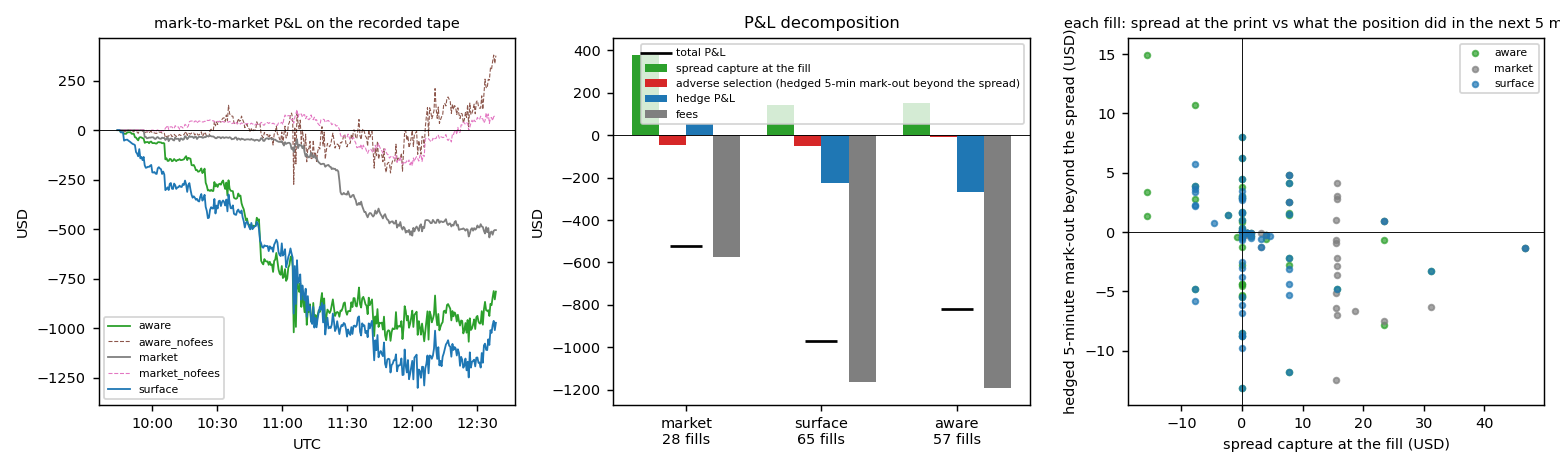

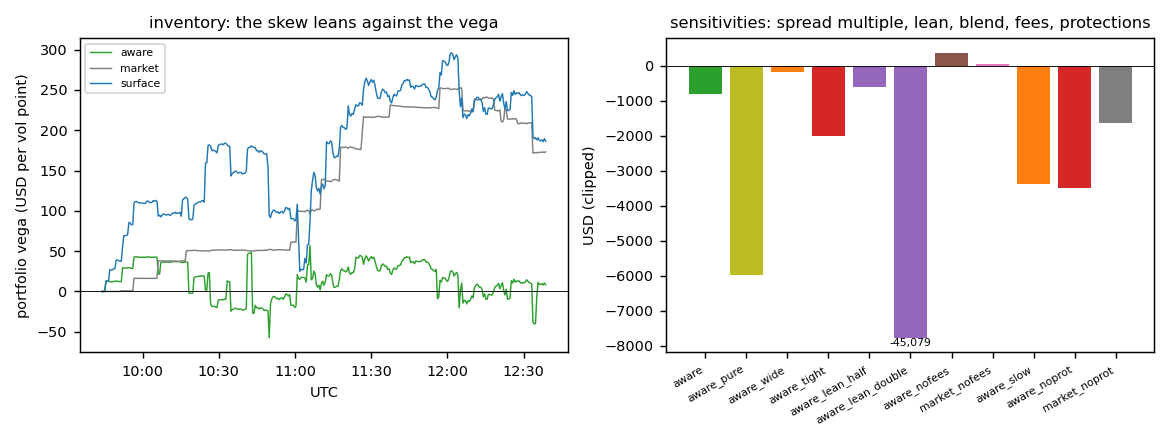

In [4]:
m = run.get('mm', {}); runs = m.get('runs', {})
cols = ['fills', 'contracts', 'pnl_usd', 'pnl_per_contract_usd', 'spread_capture_usd', 'spread_vs_fair_usd', 'markout_5m_usd', 'markout_dh_5m_usd', 'adverse_selection_5m_usd', 'fees_usd', 'hedge_pnl_usd', 'n_hedges', 'n_pulls', 'max_abs_vega', 'max_abs_delta_btc', 'avg_quotes']
tab = pd.DataFrame({k: {c: v.get(c) for c in cols} for k, v in runs.items()}).T
display(tab.round(1))
display(Image('results/figures/mm.png'))
display(Image('results/figures/mm_inventory.png'))

Spread capture is the fill against Deribit's mark at the print; `spread_vs_fair` against our own fair; the hedged 5-minute mark-out removes the delta times the index move; adverse selection is that mark-out beyond the spread captured. The `_nofees` runs are the economics of a participant on the exchange's liquidity-provider programme; `_slow` re-prices on the timer only; `_noprot` has no protections at all.

In [6]:
fills = pd.read_parquet(os.path.join(DER, 'mm_fills.parquet')) if os.path.exists(os.path.join(DER, 'mm_fills.parquet')) else pd.DataFrame()
if len(fills):
    f = fills[fills['quoter'] == 'aware'].copy(); f['t'] = pd.to_datetime(f['ts'], unit='ms', utc=True).dt.strftime('%H:%M:%S')
    display(f[['t', 'instrument', 'side', 'amount', 'price_usd', 'mark_usd', 'fair_usd', 'spread_capture_usd', 'markout_dh_5m_usd', 'fee_usd', 'port_vega_before']].head(20).round(2))
    print('by quoter: fills, spread capture, hedged 5-minute mark-out')
    display(fills.groupby('quoter')[['spread_capture_usd', 'markout_dh_5m_usd', 'fee_usd']].agg(['count', 'sum']).round(0))

by quoter: fills, spread capture, hedged 5-minute mark-out


,t,instrument,side,amount,price_usd,mark_usd,fair_usd,spread_capture_usd,markout_dh_5m_usd,fee_usd,port_vega_before
93,09:45:17,BTC-21SEP26-76000-P,1,1.0,85.80,85.80,95.23,-0.00,6.23,10.72,0.00
94,09:52:01,BTC-21SEP26-76500-P,1,1.0,140.52,140.52,150.88,-0.00,1.66,17.57,12.42
95,09:56:15,BTC-20SEP26-77000-P,1,1.0,124.98,124.98,138.83,-0.00,-8.81,15.62,28.69
96,10:05:54,BTC-25SEP26-78000-P,-1,1.0,1250.38,1234.75,1215.01,15.63,10.87,23.44,42.10
97,10:06:01,BTC-25SEP26-83000-C,1,1.0,218.64,226.44,236.29,7.81,11.97,23.43,0.06
98,10:06:43,BTC-20SEP26-77000-P,1,1.0,117.16,117.16,129.06,-0.00,0.81,14.65,21.51
99,10:18:11,BTC-25SEP26-80000-C,-1,1.0,703.14,703.14,682.74,0.00,-13.14,23.44,36.19
100,10:20:04,BTC-25SEP26-74000-P,1,1.0,211.00,203.18,220.16,-7.81,-3.95,23.44,-2.49
101,10:24:39,BTC-25SEP26-80000-C,-1,1.0,703.11,710.92,685.87,-7.81,2.90,23.44,18.98
102,10:24:45,BTC-25SEP26-74000-P,1,1.0,210.92,210.92,222.45,-0.00,2.83,23.44,-19.27


spread_capture_usd          markout_dh_5m_usd          fee_usd         
                               count      sum             count      sum   count      sum
quoter                                                                                   
aware                             57    151.0                54    140.0      57    958.0
aware_lean_double                867 -18411.0               866 -19784.0     867  18682.0
aware_lean_half                   53    143.0                51    107.0      53    829.0
aware_nofees                      57    151.0                54    140.0      57      0.0
aware_noprot                      97    -85.0                96   -304.0      97   1829.0
aware_pure                       201  -1864.0               192  -1732.0     201   3348.0
aware_slow                       119   -410.0               118   -530.0     119   2292.0
aware_tight                      125    -18.0               124    -79.0     125   2018.0
aware_wide                        34    197.0                32    164.0      34    533.0
market                            28    377.0                28    331.0      28    430.0
market_nofees                     28    377.0                28    331.0      28      0.0
market_noprot                     46    359.0                46     60.0      46    836.0
surface                           65    140.0                65     86.0      65    939.0
surface_pure                     129   -384.0               123   -313.0     129   1912.0

## 2. The surface on the tape

Our implied vols from the quotes (C++ solver), the forward from the ticker, one eSSVI slice per expiry with the butterfly conditions applied as a clamp and the calendar ordering enforced, a numerical Durrleman check on the quoted range after every fit.

{'n_surfaces': 174, 'n_slices': 1173, 'step_s': 60, 'hours': 2.883, 'rmse_vol_points_mean': 0.76, 'rmse_vol_points_median': 0.742, 'max_err_vol_points_median': 4.533, 'butterfly_violations_total': 0, 'calendar_ok_share': 1.0, 'within_spread_share_mean': 0.88, 'mark_iv_abs_diff_volpts_median': 0.523, 'quotes_per_surface': 130.155, 'expiries_days': [1, 2, 3, 4, 7, 21, 70], 'seconds': 94.1}


,atm_vol,rr25
1,0.2777,-0.0496
2,0.2238,-0.0338
3,0.2397,-0.0302
4,0.2723,-0.0201
7,0.2998,-0.0082
21,0.3180,0.0084
70,0.3533,0.0189


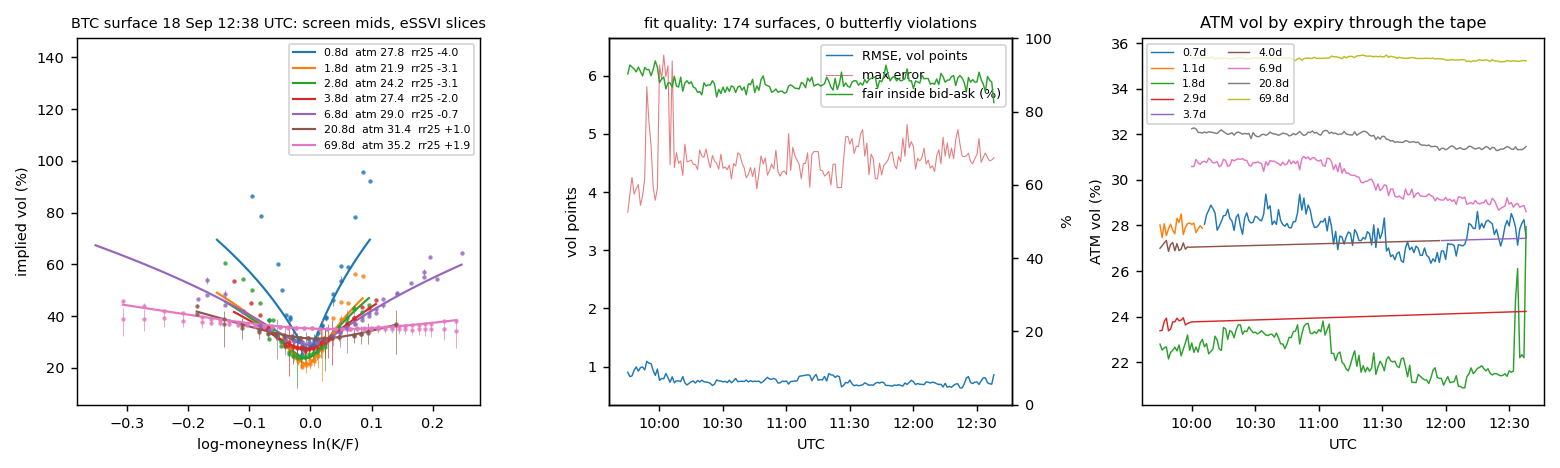

In [8]:
ts = run.get('tape_surfaces', {})
print({k: (round(v, 3) if isinstance(v, float) else v) for k, v in ts.items() if k not in ('atm_vol_by_expiry', 'rr25_by_expiry')})
display(pd.DataFrame({'atm_vol': ts.get('atm_vol_by_expiry', {}), 'rr25': ts.get('rr25_by_expiry', {})}).round(4))
display(Image('results/figures/surface.png'))

In [9]:
import duckdb
con = duckdb.connect(os.path.join(DER, 'optmm.duckdb'), read_only=True)
for q in ["select round(T*365.25,1) as days, count(*) as n_fits, round(avg(rmse_vol)*100,3) as rmse_volpts, round(avg(atm_vol)*100,2) as atm_vol, round(avg(rr25)*100,2) as rr25, sum(case when butterfly_ok then 0 else 1 end) as butterfly_violations from surfaces group by 1 order by 1",
          "select quoter, count(*) as fills, round(sum(spread_capture_usd)) as spread_capture, round(sum(markout_dh_5m_usd)) as hedged_markout_5m, round(sum(fee_usd)) as fees from mm_fills group by 1 order by 1"]:
    try:
        display(con.execute(q).df())
    except Exception as e:
        print('no table yet:', str(e)[:80])
con.close()

,days,n_fits,rmse_volpts,atm_vol,rr25,butterfly_violations
0,0.8,63,0.799,27.33,-4.83,0.0
1,0.9,111,0.854,28.01,-5.03,0.0
2,1.8,63,0.596,21.71,-3.66,0.0
3,1.9,111,1.111,22.76,-3.22,0.0
4,2.8,63,1.059,24.13,-3.04,0.0
5,2.9,111,1.047,23.87,-3.02,0.0
6,3.8,63,0.427,27.36,-2.03,0.0
7,3.9,111,0.424,27.15,-2.00,0.0
8,6.8,63,1.117,29.10,-0.60,0.0
9,6.9,96,1.059,30.55,-0.97,0.0


,quoter,fills,spread_capture,hedged_markout_5m,fees
0,aware,57,151.0,140.0,958.0
1,aware_lean_double,867,-18411.0,-19784.0,18682.0
2,aware_lean_half,53,143.0,107.0,829.0
3,aware_nofees,57,151.0,140.0,0.0
4,aware_noprot,97,-85.0,-304.0,1829.0
5,aware_pure,201,-1864.0,-1732.0,3348.0
6,aware_slow,119,-410.0,-530.0,2292.0
7,aware_tight,125,-18.0,-79.0,2018.0
8,aware_wide,34,197.0,164.0,533.0
9,market,28,377.0,331.0,430.0


## 3. Microstructure of quoting

How long the screen's best quotes stay put after the index moves and what a stale quote would have given up; spread and depth by tenor and moneyness; block prints against the mark.

{'events': 50, 'window_s': 30, 'threshold_bp': 5.0, 'pairs': 10393, 'median_latency_s': 23.785, 'share_stale_5s': 0.85, 'share_stale_30s': 0.313, 'mean_pickoff_loss_usd': 0.315, 'mean_pickoff_loss_volpts': 0.809, 'share_move_exceeds_half_spread': 0.032}


,n,median_latency_s,share_stale_5s,mean_loss_usd,share_exceeds_half_spread
5-8bp,9764.0,24.653,0.866,0.038,0.016
8-12bp,419.0,18.600,0.797,0.539,0.105
12-20bp,210.0,3.599,0.210,12.736,0.643


,tenor,moneyness,instruments,spread_volpts,rel_spread_pct,bid_size,ask_size,two_sided_share
0,<2d,deep put,41,4.24,7.57,9.0,9.1,1.0
1,<2d,put,14,2.44,20.00,9.0,9.0,1.0
2,<2d,atm,14,3.53,13.59,19.6,18.7,1.0
3,<2d,call,18,2.43,18.18,9.0,8.5,1.0
4,<2d,deep call,21,4.96,10.26,21.1,7.9,1.0
5,2-10d,deep put,48,2.81,3.36,11.8,11.5,1.0
6,2-10d,put,26,2.29,7.91,8.8,9.9,1.0
7,2-10d,atm,26,1.90,6.32,27.3,34.4,1.0
8,2-10d,call,30,2.15,8.28,9.6,8.7,1.0
9,2-10d,deep call,41,2.83,5.35,10.3,7.3,1.0


,all,block,screen
trades,2.424223e+06,3.305890e+05,2093634.000
contracts,2.010906e+07,1.729451e+07,2814551.100
median_abs_diff_pct,1.897000e+00,1.622000e+00,1.952
median_diff_volpts,-5.700000e-02,9.000000e-03,-0.068
mean_diff_volpts,1.600000e-02,1.090000e-01,0.001
median_abs_diff_volpts,5.540000e-01,5.060000e-01,0.562
aggressor_cost_pct_median,7.640000e-01,1.239000e+00,0.652


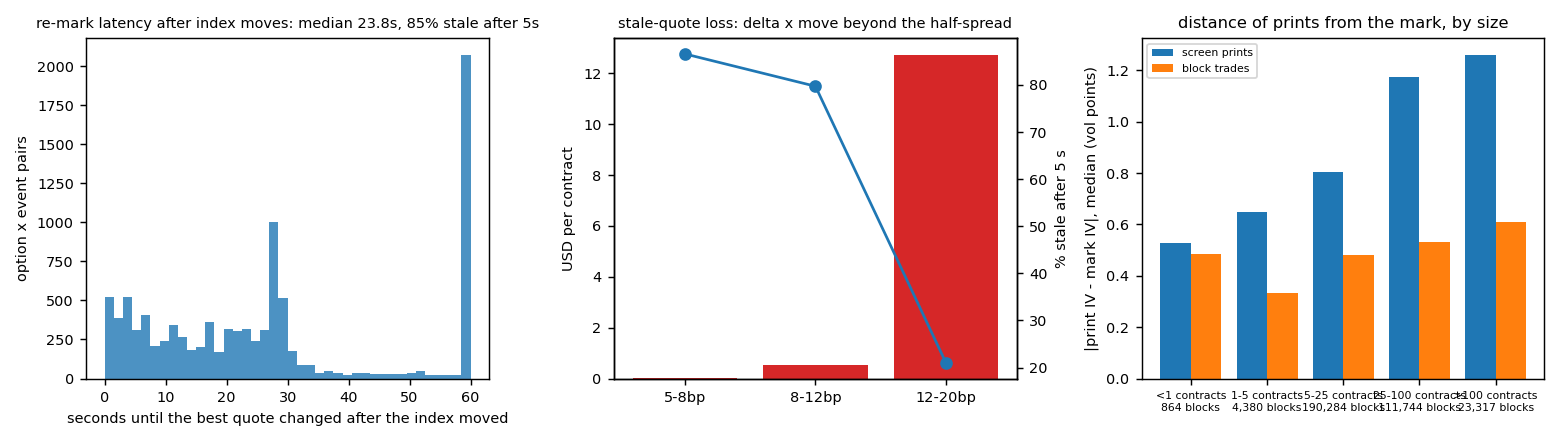

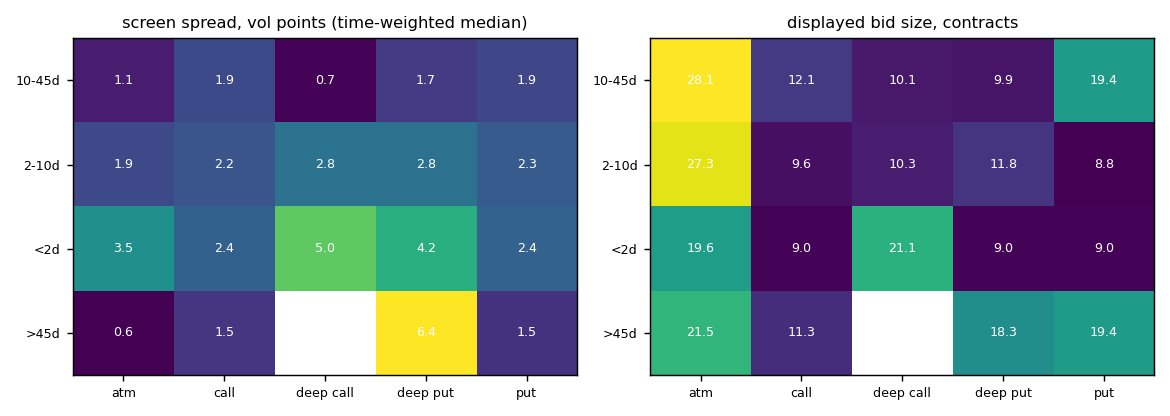

In [11]:
mi = run.get('micro', {}); pk = mi.get('pickoff', {})
print({k: (round(v, 3) if isinstance(v, float) else v) for k, v in pk.items() if k != 'by_bucket'})
if pk.get('by_bucket'):
    display(pd.DataFrame(pk['by_bucket']).T.round(3))
display(pd.DataFrame(mi.get('spread_depth', [])).round(2))
b = mi.get('blocks', {})
if b:
    display(pd.DataFrame({k: b[k] for k in ('all', 'block', 'screen')}).round(3))
display(Image('results/figures/micro.png'))
display(Image('results/figures/spread_depth.png'))

## 4. The RFQ pricer

Structures priced off the latest surface with the package Greeks and a spread rule: the sum of the legs' half-spreads in vol through their vegas, times a package factor (1 leg 1.0, 2 legs 0.6, 3 legs 0.8).

In [13]:
r = run.get('rfq', {})
print('as of', pd.to_datetime(r.get('asof', 0), unit='ms', utc=True), 'index', r.get('index'))
for k, v in r.items():
    if isinstance(v, dict) and 'quote' in v:
        print(f"{k:14s} {v['quote']}")

as of 2026-09-18 12:38:45.270000+00:00 index 78056.01
straddle       +1 C78000 2d @ 21.8v, +1 P78000 2d @ 21.8v | mid 9,541 bid 9,073 ask 10,009 (half-spread 468, factor 0.6) | delta 0.528 gamma 0.006666 vega 43,710/vol theta -2,632/day
strangle       +1 P74000 2d @ 31.5v, +1 C82000 2d @ 37.6v | mid 304 bid 267 ask 341 (half-spread 37, factor 0.6) | delta 0.249 gamma 0.000474 vega 5,143/vol theta -516/day
risk_reversal  +1 C82000 2d @ 37.6v, -1 P74000 2d @ 31.5v | mid 217 bid 180 ask 254 (half-spread 37, factor 0.6) | delta 0.401 gamma 0.000232 vega 2,845/vol theta -315/day
butterfly      +1 C74000 2d @ 31.5v, -2 C78000 2d @ 21.8v, +1 C82000 2d @ 37.6v | mid 30,763 bid 30,089 ask 31,437 (half-spread 674, factor 0.8) | delta -0.279 gamma -0.006193 vega -38,567/vol theta 2,116/day
calendar       +1 C78000 70d @ 35.4v, -1 C78000 2d @ 21.8v | mid 47,236 bid 46,676 ask 47,797 (half-spread 561, factor 0.6) | delta 0.303 gamma -0.003009 vega 114,172/vol theta 971/day


## 5. Surfaces from the trade history and the listed chains

One SSVI surface a day from the Deribit prints in the two hours before the 08:00 UTC settlement since 2021; daily SVI surfaces for SPY, AAPL and NVDA from the DoltHub end-of-day chains with the forward from put-call parity.

{'n_slices': 11429, 'n_days': 2086, 'months': ['202101', '202609'], 'trades_used': 1731137, 'rmse_vol_points_mean': 1.609, 'rmse_vol_points_median': 1.398, 'butterfly_violations': 0, 'calendar_ok_share': 1.0, 'seconds': 531.4}


,days,rmse_vol_points,calendar_ok_share
2021,365.0,2.066,1.0
2022,364.0,1.382,1.0
2023,365.0,1.270,1.0
2024,366.0,1.752,1.0
2025,365.0,1.695,1.0
2026,261.0,1.436,1.0


,atm_vol,rr25
p5,0.2953,-0.0238
p25,0.4035,0.0086
p50,0.5103,0.0334
p75,0.6733,0.0648
p95,0.9322,0.1330


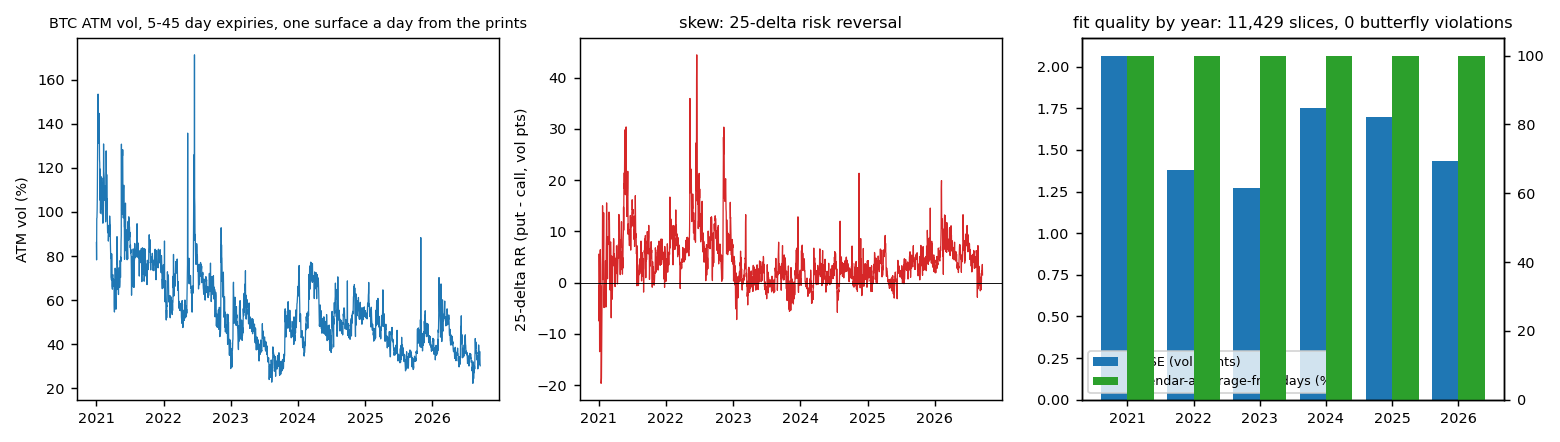

,days,days_fitted,from,to,slices,quotes,rmse_vol_points_mean,rmse_vol_points_median,max_err_vol_points_median,within_spread_share_mean,rmse_half_spreads_median,butterfly_violations,calendar_ok_share,vendor_iv_abs_diff_volpts_median,atm_vol_front_median,rr25_front_median
SPY,619,619,2024-01-03,2026-09-17,2062,36894,0.459131,0.465786,1.468709,0.176483,15.622514,0,1.0,0.137877,0.1274,0.0311
AAPL,623,623,2024-01-03,2026-09-17,2012,35720,0.27173,0.215662,0.775562,0.598965,3.461046,0,1.0,0.213342,0.2399,0.0218
NVDA,622,622,2024-01-03,2026-09-17,2043,42224,0.447536,0.340455,1.456336,0.541453,2.96238,0,1.0,0.358497,0.41155,0.0323


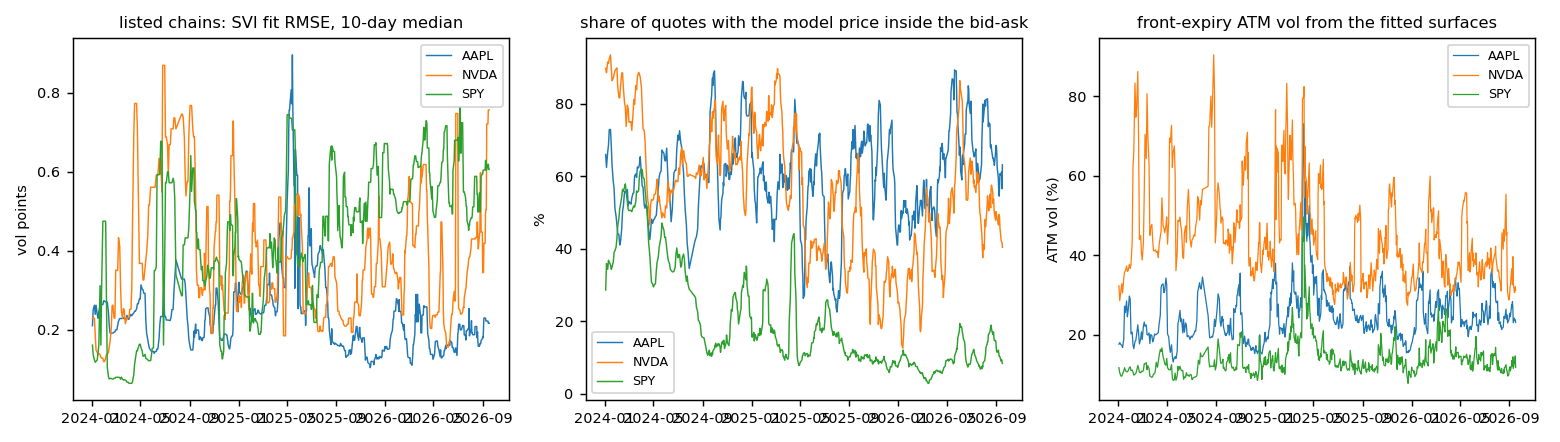

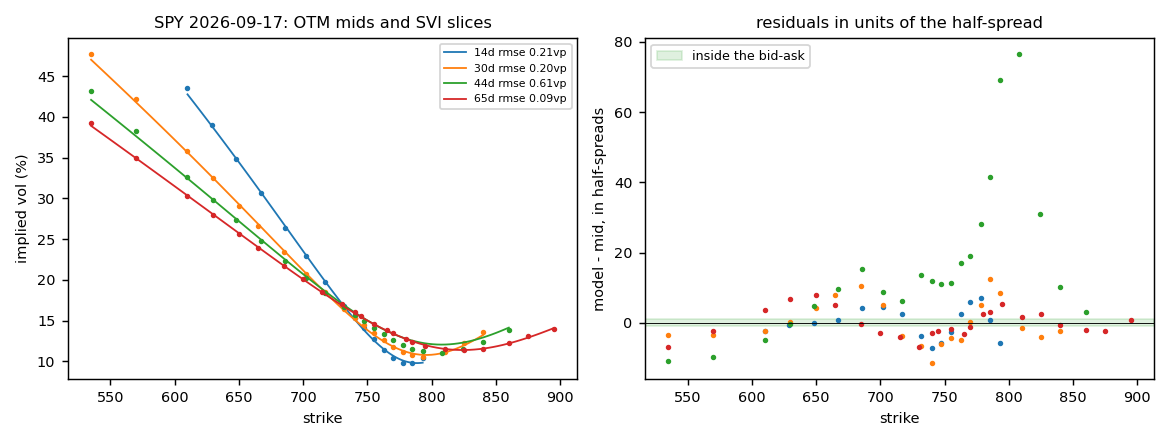

In [15]:
h = run.get('history_surfaces', {})
print({k: (round(v, 3) if isinstance(v, float) else v) for k, v in h.items() if k not in ('by_year', 'atm_vol_percentiles', 'rr25_percentiles')})
display(pd.DataFrame(h.get('by_year', {})).T.round(3))
display(pd.DataFrame({'atm_vol': h.get('atm_vol_percentiles', {}), 'rr25': h.get('rr25_percentiles', {})}).round(4))
display(Image('results/figures/history.png'))
ch = {k: v for k, v in run.get('chains', {}).items() if isinstance(v, dict)}
display(pd.DataFrame(ch).T.round(3))
display(Image('results/figures/chains.png'))
display(Image('results/figures/chains_example.png'))